In [1]:
import re, time
from utils.bool_parser import parse_expr, flatten_nary, sanitize

src = open('inputs/puzzle.v').read()
lines = [re.sub(r'//.*', '', l) for l in src.splitlines()]
src = '\n'.join(lines)

assign_re = re.compile(r'assign\s+([A-Za-z_][A-Za-z0-9_\[\]]*)\s*=\s*(.*?);', re.DOTALL)
assigns = {}
order = []
for name, expr in assign_re.findall(src):
    expr = re.sub(r'\s+', ' ', expr).strip()
    name = name.strip()
    if name in assigns:
        continue
    assigns[name] = expr
    order.append(name)

regs = set(re.findall(r'\breg\s+([A-Za-z_][A-Za-z0-9_]*)\s*;', src))
regs |= set(re.findall(r'output\s+reg\s+([A-Za-z_][A-Za-z0-9_]*)', src))

always_blocks = re.findall(r'always\s*@\([^)]*\)\s*begin(.*?)end\s*(?=always|endmodule)', src, re.DOTALL)
reset_vals, next_expr = {}, {}
for blk in always_blocks:
    m = re.search(r'if\s*\(\s*!\s*rst_n\s*\)\s*begin(.*?)end\s*else\s*begin(.*?)end', blk, re.DOTALL)
    reset_part, next_part = m.groups() if m else ('', blk)
    for nm, val in re.findall(r"([A-Za-z_][A-Za-z0-9_\[\]]*)\s*<=\s*(.*?);", reset_part, re.DOTALL):
        reset_vals[sanitize(nm.strip())] = re.sub(r'\s+', ' ', val).strip()
    for nm, val in re.findall(r"([A-Za-z_][A-Za-z0-9_\[\]]*)\s*<=\s*(.*?);", next_part, re.DOTALL):
        next_expr[sanitize(nm.strip())] = re.sub(r'\s+', ' ', val).strip()

san_assigns = {sanitize(n): v for n, v in assigns.items()}
comb_names = set(san_assigns)

# depth order (same technique as before) so we encode each gate after its fan-in
def ids_of(expr):
    return set(re.findall(r'[A-Za-z_][A-Za-z0-9_]*', expr))

depth_cache = {}
def depth(net, stack=frozenset()):
    if net in depth_cache: return depth_cache[net]
    if net not in san_assigns or net in stack: return 0
    deps = ids_of(san_assigns[net]) & comb_names
    d = 1 + max((depth(dep, stack | {net}) for dep in deps), default=-1)
    depth_cache[net] = d
    return d
for n in comb_names:
    depth(n)
comb_order = sorted(comb_names, key=depth)

reg_names = sorted(sanitize(r) for r in regs)

# ---------------- Tseitin CNF builder ----------------
class CNF:
    def __init__(self):
        self.nvars = 0
        self.clauses = []
    def new_var(self):
        self.nvars += 1
        return self.nvars
    def add(self, *lits):
        self.clauses.append(list(lits))

cnf = CNF()
TRUE_VAR = cnf.new_var();  cnf.add(TRUE_VAR)
FALSE_VAR = cnf.new_var(); cnf.add(-FALSE_VAR)

def lit_and(cnf, lits):
    z = cnf.new_var()
    for l in lits:
        cnf.add(-z, l)
    cnf.add(z, *[-l for l in lits])
    return z

def lit_or(cnf, lits):
    z = cnf.new_var()
    for l in lits:
        cnf.add(z, -l)
    cnf.add(-z, *lits)
    return z

def lit_xor2(cnf, a, b):
    z = cnf.new_var()
    cnf.add(-z, -a, -b)
    cnf.add(-z, a, b)
    cnf.add(z, -a, b)
    cnf.add(z, a, -b)
    return z

def lit_mux(cnf, cond, a, b):
    z = cnf.new_var()
    cnf.add(-z, -cond, a)
    cnf.add(-z, cond, b)
    cnf.add(z, -cond, -a)
    cnf.add(z, cond, -b)
    return z

def encode_ast(node, env):
    """env: name -> literal (int). Returns a literal for this AST node."""
    if node.kind == 'const':
        return TRUE_VAR if node.args[0] == 1 else FALSE_VAR
    if node.kind == 'var':
        return env[node.args[0]]
    if node.kind == 'not':
        return -encode_ast(node.args[0], env)
    if node.kind == 'and':
        return lit_and(cnf, [encode_ast(a, env) for a in node.args])
    if node.kind == 'or':
        return lit_or(cnf, [encode_ast(a, env) for a in node.args])
    if node.kind == 'xor':
        l = encode_ast(node.args[0], env)
        for a in node.args[1:]:
            l = lit_xor2(cnf, l, encode_ast(a, env))
        return l
    if node.kind == 'mux':
        c = encode_ast(node.args[0], env)
        a = encode_ast(node.args[1], env)
        b = encode_ast(node.args[2], env)
        return lit_mux(cnf, c, a, b)
    raise ValueError(node.kind)

parsed_cache = {}
def get_ast(expr):
    if expr not in parsed_cache:
        parsed_cache[expr] = flatten_nary(parse_expr(expr))
    return parsed_cache[expr]

T = 122
I_vars = []          # I_vars[t] = literal for I at cycle t (free variable)
comb_lit = {}        # (name) -> literal, reset each cycle
reg_val = {r: (TRUE_VAR if reset_vals.get(r) == "1'b1" else FALSE_VAR) for r in reg_names}

t0 = time.time()
comb_lit_per_cycle = []  # for external validation: comb_lit_per_cycle[t] = {name: var_id}
for t in range(T):
    It = cnf.new_var()
    I_vars.append(It)
    env = dict(reg_val)   # register reads see the value ENTERING this cycle
    env['I'] = It
    env['enable'] = TRUE_VAR    # fixed: enable=1 every cycle in our chosen envelope
    env['rst_n'] = TRUE_VAR     # fixed: no reset within this window
    comb_lit = {}
    for name in comb_order:
        ast = get_ast(san_assigns[name])
        lit = encode_ast(ast, {**env, **comb_lit})
        comb_lit[name] = lit
        env[name] = lit  # so later same-cycle refs (regs read as env already; combs added incrementally)
    comb_lit_per_cycle.append(comb_lit)
    # register updates for next cycle
    new_reg_val = {}
    for r in reg_names:
        nx = next_expr.get(r)
        if nx is None:
            new_reg_val[r] = reg_val[r]
            continue
        ast = get_ast(nx)
        new_reg_val[r] = encode_ast(ast, {**env, **comb_lit})
    reg_val = new_reg_val
    if t % 20 == 0:
        print(f"cycle {t}: vars={cnf.nvars} clauses={len(cnf.clauses)} elapsed={time.time()-t0:.1f}s")

print(f"\nDone unrolling {T} cycles. vars={cnf.nvars} clauses={len(cnf.clauses)} time={time.time()-t0:.1f}s")

# Force success (the register's value ENTERING cycle T, i.e. after the cycle-(T-1) update) = 1
success_lit = reg_val['success']
cnf.add(success_lit)

# ---- write DIMACS CNF ----
out_path = 'inputs/puzzle_success.cnf'
with open(out_path, 'w') as f:
    f.write(f"c Puzzle success=1 SAT instance\n")
    f.write(f"c Free variables: I_0 .. I_{T-1} (the serial input bit stream), one per clock cycle 0..{T-1}\n")
    f.write(f"c enable=1, rst_n=1 fixed for all {T} cycles (matches the real 'rounds complete' envelope)\n")
    f.write(f"c 'rounds complete' window at cycle {T-1} is enable-only-driven, independent of I -- confirmed separately\n")
    f.write(f"c TRUE_VAR={TRUE_VAR} FALSE_VAR={FALSE_VAR}\n")
    for t, v in enumerate(I_vars):
        f.write(f"c I_{t} = var {v}\n")
    f.write(f"p cnf {cnf.nvars} {len(cnf.clauses)}\n")
    for cl in cnf.clauses:
        f.write(' '.join(map(str, cl)) + ' 0\n')

print("Wrote", out_path)

# save the I-variable map separately too, for easy decoding of a solver's model
with open('inputs/puzzle_success.varmap.txt', 'w') as f:
    for t, v in enumerate(I_vars):
        f.write(f"I_{t} {v}\n")
    f.write(f"success_at_cycle_{T-1} {success_lit}\n")
print("Wrote puzzle_success.varmap.txt")

cycle 0: vars=829 clauses=2835 elapsed=0.1s
cycle 20: vars=17369 clauses=59495 elapsed=0.6s
cycle 40: vars=33909 clauses=116155 elapsed=1.1s
cycle 60: vars=50449 clauses=172815 elapsed=1.5s
cycle 80: vars=66989 clauses=229475 elapsed=2.0s
cycle 100: vars=83529 clauses=286135 elapsed=2.4s
cycle 120: vars=100069 clauses=342795 elapsed=2.8s

Done unrolling 122 cycles. vars=100896 clauses=345628 time=2.8s
Wrote inputs/puzzle_success.cnf
Wrote puzzle_success.varmap.txt


In [2]:
# Install MiniSat
#!apt-get update -qq
#!apt-get install -y minisat

In [3]:
#!unzip files_cnf_sat_solver_for_js03.zip

In [7]:
!minisat inputs/puzzle_success.cnf model.txt

============================[ Problem Statistics ]=============================
|                                                                             |
|  Number of variables:        100896                                         |
|  Number of clauses:           93007                                         |
|  Parse time:                   0.09 s                                       |
|  Eliminated clauses:           0.74 Mb                                      |
|  Simplification time:          0.16 s                                       |
|                                                                             |
============================[ Search Statistics ]==============================
| Conflicts |          ORIGINAL         |          LEARNT          | Progress |
|           |    Vars  Clauses Literals |    Limit  Clauses Lit/Cl |          |
restarts              : 1
conflicts             : 36             (138 /sec)
decisions             : 109            (0.00

In [16]:
# Decode logic
import sys
def load_varmap(path='inputs/puzzle_success.varmap.txt'):
    I_var = {}
    success_var = None
    with open(path) as f:
        for line in f:
            name, var = line.split()
            if name.startswith('I_'):
                I_var[int(name[2:])] = int(var)
            elif name.startswith('success_at_cycle_'):
                success_var = int(var)
    return I_var, success_var

def load_model(path):
    text = open(path).read()
    text = text.replace('SAT', ' ').replace('v', ' ')
    return {abs(int(tok)): (int(tok) > 0) for tok in text.split() if tok.lstrip('-').isdigit()}

def decode(model_path):
    I_var, success_var = load_varmap()
    model = load_model(model_path)
    T = len(I_var)
    I_seq = [1 if model.get(I_var[t], False) else 0 for t in range(T)]
    return I_seq

I_success = decode('model.txt')
print("I_success =", I_success)

I_success = [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]


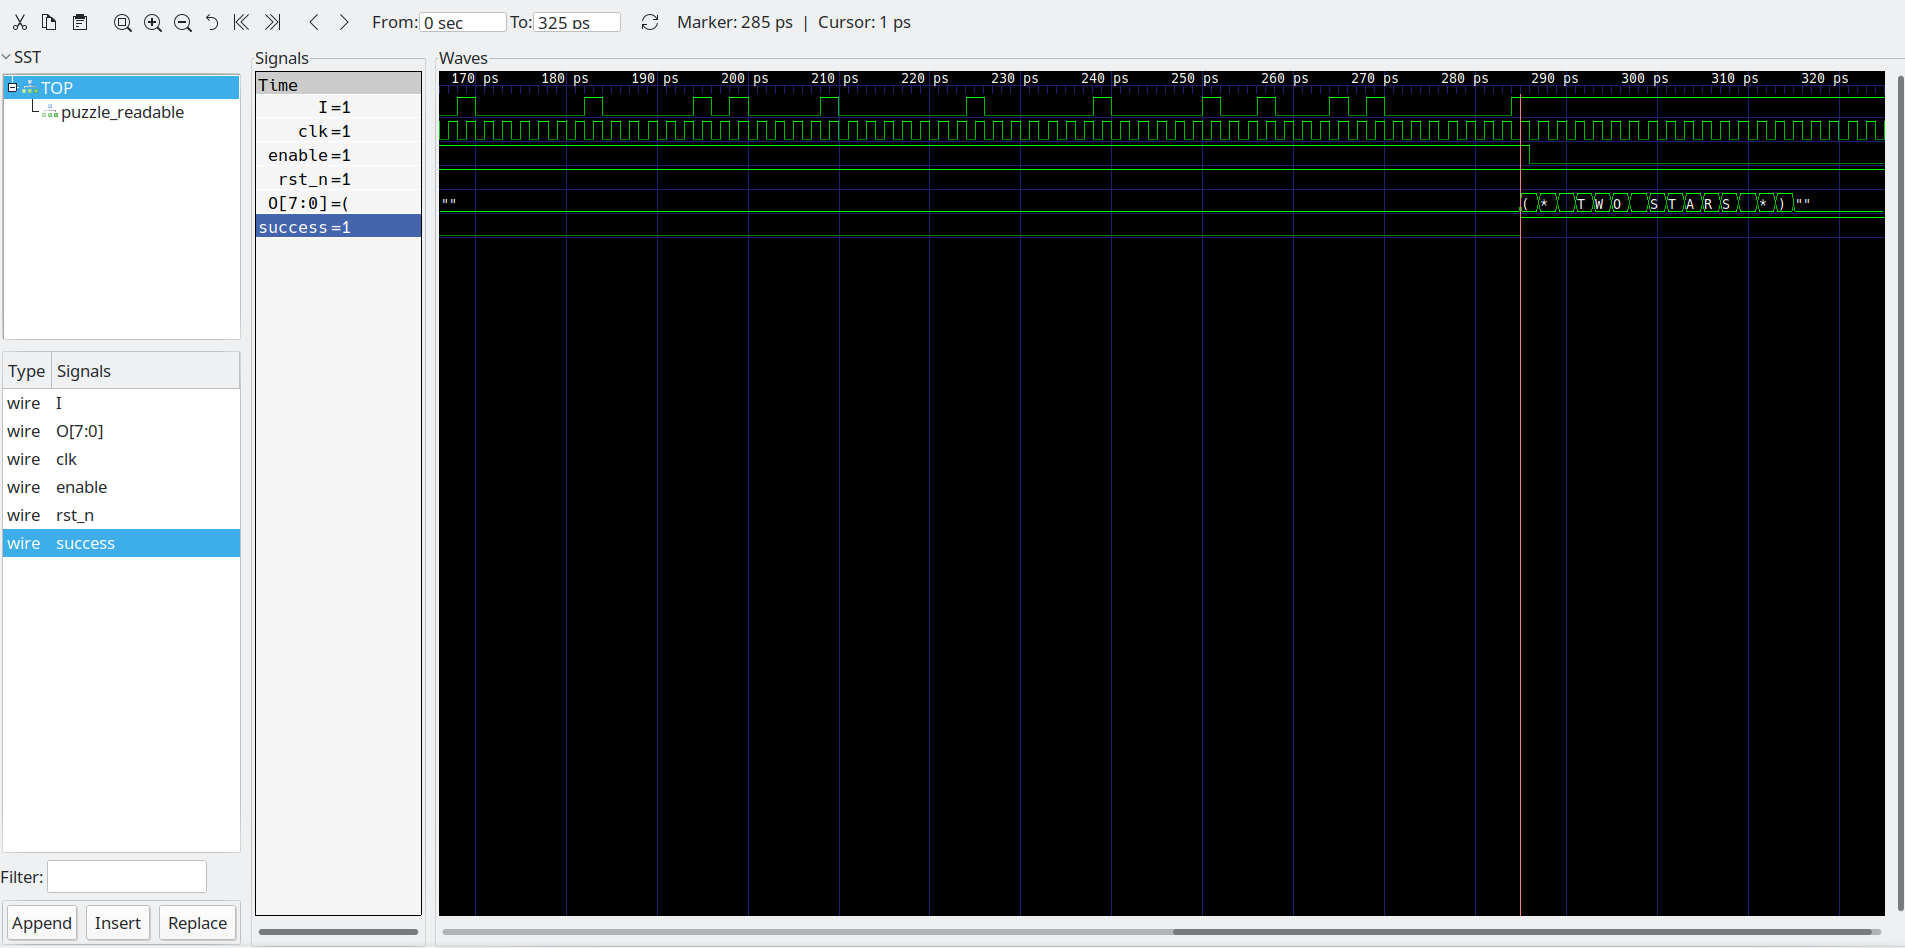